# Produccion por Ingredientes

In [4]:
import pandas as pd

pi = pd.read_excel("Produccion por Ingredientes final.xlsx")
pi

ModuleNotFoundError: No module named 'pandas'

In [5]:
pi = pd.read_excel("Produccion por Ingredientes final.xlsx", header=3)
pi

NameError: name 'pd' is not defined

# Producción por Mes

In [ ]:
pm = pd.read_excel("Producción por Mes NFS.xlsx", header=1)
pm

,PRODUCTO,1 AL 7,8,9,10,11,12,13,14,15,...,24,25,26,27,28,29,30,31,TOTAL MENSUAL (KG),PROMEDIO
0,AJI ENCURTIDO CDP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
1,AJO CONFITADO (PA) NFS,NaN,NaN,NaN,NaN,NaN,NaN,20.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.51,41.755000
2,AJO Y ZANAHORIA CONFITADO NFS (PA),NaN,15.00,81.94,NaN,NaN,NaN,NaN,6.0,13.31,...,10.50,37.67,NaN,NaN,NaN,78.34,NaN,NaN,268.02,33.502500
3,BABAGANUSH x KG LPR (PA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
4,BOTON GREEN NFS (PA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.70,6.700000
5,CALDO POLLO ARVERJADO CDP (PA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
6,CALENTITO CHARQUICAN NFS (PA),NaN,115.87,NaN,131.73,NaN,NaN,122.56,NaN,125.00,...,NaN,NaN,NaN,NaN,NaN,125.10,NaN,NaN,998.26,124.782500
7,CALENTITO PURE DE MANZANA (PA),NaN,61.67,NaN,NaN,NaN,NaN,NaN,NaN,171.00,...,51.88,55.00,NaN,NaN,NaN,NaN,NaN,NaN,339.55,84.887500
8,CALENTITO PURE DE PAPAS NFS (PA),NaN,NaN,NaN,224.50,NaN,NaN,NaN,NaN,90.00,...,77.00,74.38,NaN,NaN,NaN,NaN,78.00,NaN,760.54,95.067500
9,CALENTITO PURE DE ZAPALLO (PA),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,50.32,NaN,50.00,NaN,NaN,47.52,NaN,313.41,62.682000


In [ ]:
archivo = "Producción por Mes NFS.xlsx"
anio = 2025

map_mes = {
    'ENE': 1, 'FEB': 2, 'MAR': 3, 'ABR': 4,
    'MAY': 5, 'JUN': 6, 'JUL': 7, 'AGO': 8,
    'SEP': 9, 'OCT': 10, 'NOV': 11, 'DIC': 12
}

xls = pd.ExcelFile(archivo)

dfs = []

for hoja in xls.sheet_names:
    if hoja.upper().strip() not in map_mes:
        continue

    mes = map_mes[hoja.upper().strip()]

    df = pd.read_excel(
        archivo,
        sheet_name=hoja,
        header=1
    )

    # Normalizar nombre de columna
    df = df.rename(columns=lambda x: str(x).strip())

    # Pasar a formato largo
    df_long = df.melt(
        id_vars='PRODUCTO',
        var_name='DIA',
        value_name='QTY_KG'
    )

    # Limpiar filas inválidas
    df_long = df_long.dropna(subset=['QTY_KG'])

    # Asegurar día numérico
    df_long['DIA'] = pd.to_numeric(df_long['DIA'], errors='coerce')
    df_long = df_long.dropna(subset=['DIA'])

    # Crear fecha
    df_long['Fecha'] = pd.to_datetime(
        dict(
            year=anio,
            month=mes,
            day=df_long['DIA'].astype(int)
        ),
        errors='coerce'
    )

    df_long = df_long.dropna(subset=['Fecha'])

    dfs.append(
        df_long[['Fecha', 'PRODUCTO', 'QTY_KG']]
    )

df_produccion = pd.concat(dfs, ignore_index=True)

df_produccion

,Fecha,PRODUCTO,QTY_KG
0,2025-10-08,AJO Y ZANAHORIA CONFITADO NFS (PA),15.00
1,2025-10-08,CALENTITO CHARQUICAN NFS (PA),115.87
2,2025-10-08,CALENTITO PURE DE MANZANA (PA),61.67
3,2025-10-08,CHOCLO A LA CREMA (LC) NFS (PA),121.22
4,2025-10-08,CRIOLLA CUCHILLO NFS (PA),35.00
...,...,...,...
619,2025-01-19,GAZPACHO NFS (PA),100.00
620,2025-01-19,PARMESANO,4.00
621,2025-01-19,PATE PIMENTON ASADO,108.00
622,2025-01-19,PERSILADE NFS (PA),22.00


In [ ]:
df_produccion['Mes'] = df_produccion['Fecha'].dt.to_period('M').astype(str)
df_produccion

,Fecha,PRODUCTO,QTY_KG,Mes
0,2025-10-08,AJO Y ZANAHORIA CONFITADO NFS (PA),15.00,2025-10
1,2025-10-08,CALENTITO CHARQUICAN NFS (PA),115.87,2025-10
2,2025-10-08,CALENTITO PURE DE MANZANA (PA),61.67,2025-10
3,2025-10-08,CHOCLO A LA CREMA (LC) NFS (PA),121.22,2025-10
4,2025-10-08,CRIOLLA CUCHILLO NFS (PA),35.00,2025-10
...,...,...,...,...
619,2025-01-19,GAZPACHO NFS (PA),100.00,2025-01
620,2025-01-19,PARMESANO,4.00,2025-01
621,2025-01-19,PATE PIMENTON ASADO,108.00,2025-01
622,2025-01-19,PERSILADE NFS (PA),22.00,2025-01


In [ ]:
df_produccion2 = (
    df_produccion
        .groupby(['Mes', 'PRODUCTO'], as_index=False)
        .agg(QTY_KG=('QTY_KG', 'sum'))
)

df_produccion2

,Mes,PRODUCTO,QTY_KG
0,2025-01,AJO Y ZANAHORIA CONFITADO NFS (PA),242.50
1,2025-01,BABAGANUSH x KG LPR (PA),13.00
2,2025-01,BOTON ENELDO (PA),10.00
3,2025-01,CALDO POLLO ARVERJADO CDP (PA),22.60
4,2025-01,CALENTITO CHARQUICAN NFS (PA),646.57
...,...,...,...
163,2025-12,RELLENO CAMARON,25.37
164,2025-12,RELLENO ENTRAÑA,101.72
165,2025-12,RELLENO POLLO,21.00
166,2025-12,SALSA POMODORO NFS (PA),42.80


# Transferencia a Centro Produccion Cocina

In [ ]:
tr_pc = pd.read_excel("Transferencia a Centro Produccion Cocina limpio.xlsx")
tr_pc

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,Suma de Qty,Etiquetas de columna,NaN,NaN,NaN,NaN
2,NaN,<01-10-2025,oct,nov,dic,Total general
3,NaN,NaN,NaN,NaN,NaN,NaN
4,Etiquetas de fila,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
167,ZAPALLO CAMOTE TROZO,NaN,800,705,900,2405
168,ZAPALLO ITALIANO,NaN,2,6,2,10
169,ZZZ@ LUPA ENCURTIDO DE VERDURAS (PA),NaN,15,NaN,NaN,15
170,(en blanco),NaN,NaN,NaN,NaN,NaN


In [ ]:
tr_pc = pd.read_excel("Transferencia a Centro Produccion Cocina limpio.xlsx", sheet_name='Base de datos')
tr_pc

,Transfer ID,From BU,To BU,Date,Status,Item Name,UOM,Qty,Cost,Extended Cost
0,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,MENTA,Kilogramo,0.00,5990.000000,0.000000
1,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,AJO PELADO,Kilogramo,0.00,4990.000000,0.000000
2,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,PEPINO ENSALADA,Kilogramo,10.00,1700.000000,17000.000000
3,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,CEBOLLIN,Kilogramo,3.00,1750.000000,5250.000000
4,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,ESPINACA DESHOJADA,Kilogramo,50.00,3800.000000,190000.000000
...,...,...,...,...,...,...,...,...,...,...
1370,ST2512-01303 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-24,Booked,ENTRAÑA NO ROLL,Kilogramo,103.03,9700.000000,999391.000000
1371,ST2512-01308 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PECHUGA DE POLLO DESHUESADA,Kilogramo,20.60,3252.761506,67006.887019
1372,ST2601-00043 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-30,Booked,Carne Molida CDP Filete (PA) (PA),Kilogramo,81.00,1284.178899,104018.490830
1373,ST2601-00046 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PAPA LAMINADA,Kilogramo,80.00,1090.000000,87200.000000


In [ ]:
tr_pc.UOM.unique()

<StringArray>
[       'Kilogramo',            'Litro',      'X Kilogramo',
    'Botella 1 Lt.',       'Bolsa 5 kg',           'Unidad',
     'Bolsa 1 Kilo',   'Botella 1,5 LT',        'X 3,78 KG',
     'Lata 425 grs',    'Bidon 1,9 lts',          'X LITRO',
 'Lata 1,880 kilos',          'X 255ML',            '1,8LT',
         'Un X 2Lt',      'Bidon 5 Lts']
Length: 17, dtype: str

In [ ]:
mapeo_uom_INV = {'Kilogramo': 'KG', 
             'Litro': 'L', 
             'X Kilogramo': 'KG', 
             'Botella 1 Lt.': 'L', 
             'Bolsa 5 kg': 'KG',
             'Unidad': 'UNI', 
             'Bolsa 1 Kilo': 'KG', 
             'Botella 1,5 LT': 'L', 
             'X 3,78 KG': 'KG',
             'Lata 425 grs': 'KG', 
             'Bidon 1,9 lts': 'L', 
             'X LITRO': 'L', 
             'Lata 1,880 kilos': 'KG',
             'X 255ML': 'L', 
             '1,8LT': 'L', 
             'Un X 2Lt': 'L', 
             'Bidon 5 Lts': 'L'}

mapeo_uom_QTY_INV = {'Kilogramo': 1, 
             'Litro': 1, 
             'X Kilogramo': 1, 
             'Botella 1 Lt.': 1, 
             'Bolsa 5 kg': 5,
             'Unidad': 1, 
             'Bolsa 1 Kilo': 1, 
             'Botella 1,5 LT': 1.5, 
             'X 3,78 KG': 3.78,
             'Lata 425 grs': 0.425, 
             'Bidon 1,9 lts': 1.9, 
             'X LITRO': 1, 
             'Lata 1,880 kilos': 1.88,
             'X 255ML': 0.255, 
             '1,8LT': 1.8, 
             'Un X 2Lt': 2, 
             'Bidon 5 Lts': 5}

df_mapeo_uom_INV = (
    pd.DataFrame(
        mapeo_uom_INV.items(),
        columns=['UOM_ORIGINAL', 'UOM_INV']
    )
)

df_mapeo_uom_QTY_INV = (
    pd.DataFrame(
        mapeo_uom_QTY_INV.items(),
        columns=['UOM_ORIGINAL', 'QTY_FACTOR']
    )
)

df_mapeo = (
    df_mapeo_uom_INV
    .merge(df_mapeo_uom_QTY_INV, on='UOM_ORIGINAL', how='left')
)

df_mapeo

,UOM_ORIGINAL,UOM_INV,QTY_FACTOR
0,Kilogramo,KG,1.000
1,Litro,L,1.000
2,X Kilogramo,KG,1.000
3,Botella 1 Lt.,L,1.000
4,Bolsa 5 kg,KG,5.000
5,Unidad,UNI,1.000
6,Bolsa 1 Kilo,KG,1.000
7,"Botella 1,5 LT",L,1.500
8,"X 3,78 KG",KG,3.780
9,Lata 425 grs,KG,0.425


In [ ]:
tr_pc2 = tr_pc.merge(df_mapeo, how='left', left_on='UOM', right_on='UOM_ORIGINAL')
tr_pc2

,Transfer ID,From BU,To BU,Date,Status,Item Name,UOM,Qty,Cost,Extended Cost,UOM_ORIGINAL,UOM_INV,QTY_FACTOR
0,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,MENTA,Kilogramo,0.00,5990.000000,0.000000,Kilogramo,KG,1.0
1,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,AJO PELADO,Kilogramo,0.00,4990.000000,0.000000,Kilogramo,KG,1.0
2,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,PEPINO ENSALADA,Kilogramo,10.00,1700.000000,17000.000000,Kilogramo,KG,1.0
3,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,CEBOLLIN,Kilogramo,3.00,1750.000000,5250.000000,Kilogramo,KG,1.0
4,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,ESPINACA DESHOJADA,Kilogramo,50.00,3800.000000,190000.000000,Kilogramo,KG,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370,ST2512-01303 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-24,Booked,ENTRAÑA NO ROLL,Kilogramo,103.03,9700.000000,999391.000000,Kilogramo,KG,1.0
1371,ST2512-01308 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PECHUGA DE POLLO DESHUESADA,Kilogramo,20.60,3252.761506,67006.887019,Kilogramo,KG,1.0
1372,ST2601-00043 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-30,Booked,Carne Molida CDP Filete (PA) (PA),Kilogramo,81.00,1284.178899,104018.490830,Kilogramo,KG,1.0
1373,ST2601-00046 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PAPA LAMINADA,Kilogramo,80.00,1090.000000,87200.000000,Kilogramo,KG,1.0


In [ ]:
tr_pc2["QTY_INV"] = tr_pc2["Qty"] * tr_pc2["QTY_FACTOR"]
tr_pc2

,Transfer ID,From BU,To BU,Date,Status,Item Name,UOM,Qty,Cost,Extended Cost,UOM_ORIGINAL,UOM_INV,QTY_FACTOR,QTY_INV
0,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,MENTA,Kilogramo,0.00,5990.000000,0.000000,Kilogramo,KG,1.0,0.00
1,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,AJO PELADO,Kilogramo,0.00,4990.000000,0.000000,Kilogramo,KG,1.0,0.00
2,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,PEPINO ENSALADA,Kilogramo,10.00,1700.000000,17000.000000,Kilogramo,KG,1.0,10.00
3,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,CEBOLLIN,Kilogramo,3.00,1750.000000,5250.000000,Kilogramo,KG,1.0,3.00
4,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,ESPINACA DESHOJADA,Kilogramo,50.00,3800.000000,190000.000000,Kilogramo,KG,1.0,50.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370,ST2512-01303 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-24,Booked,ENTRAÑA NO ROLL,Kilogramo,103.03,9700.000000,999391.000000,Kilogramo,KG,1.0,103.03
1371,ST2512-01308 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PECHUGA DE POLLO DESHUESADA,Kilogramo,20.60,3252.761506,67006.887019,Kilogramo,KG,1.0,20.60
1372,ST2601-00043 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-30,Booked,Carne Molida CDP Filete (PA) (PA),Kilogramo,81.00,1284.178899,104018.490830,Kilogramo,KG,1.0,81.00
1373,ST2601-00046 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PAPA LAMINADA,Kilogramo,80.00,1090.000000,87200.000000,Kilogramo,KG,1.0,80.00


In [ ]:
tr_pc2['Fecha'] = pd.to_datetime(tr_pc2['Date'])

tr_pc2['Mes'] = tr_pc2['Fecha'].dt.to_period('M')

df_mensual = (
    tr_pc2
        .groupby(['Mes', 'Item Name'], as_index=False)
        .agg(QTY_INV=('QTY_INV', 'sum'))
)

#df_mensual['Mes'] = df_mensual['Mes'].dt.to_timestamp()
df_mensual

,Mes,Item Name,QTY_INV
0,2025-10,@ MOLLEJAS CDP NFS (PA),40.0
1,2025-10,ACEITE FREIR,10.0
2,2025-10,ACEITE MARAVILLA,600.0
3,2025-10,ACEITE OLIVA,50.0
4,2025-10,AJI DE COLOR,11.0
...,...,...,...
346,2025-12,VINO TINTO COCINA,171.0
347,2025-12,ZANAHORIA PELADA,94.0
348,2025-12,ZANAHORIA PELADA CUBO,202.0
349,2025-12,ZAPALLO CAMOTE TROZO,900.0


In [ ]:
top10_items = (
    df_mensual
        .groupby('Item Name')['QTY_INV']
        .sum()
        .nlargest(10)
        .index
)

df_top10 = df_mensual[df_mensual['Item Name'].isin(top10_items)]

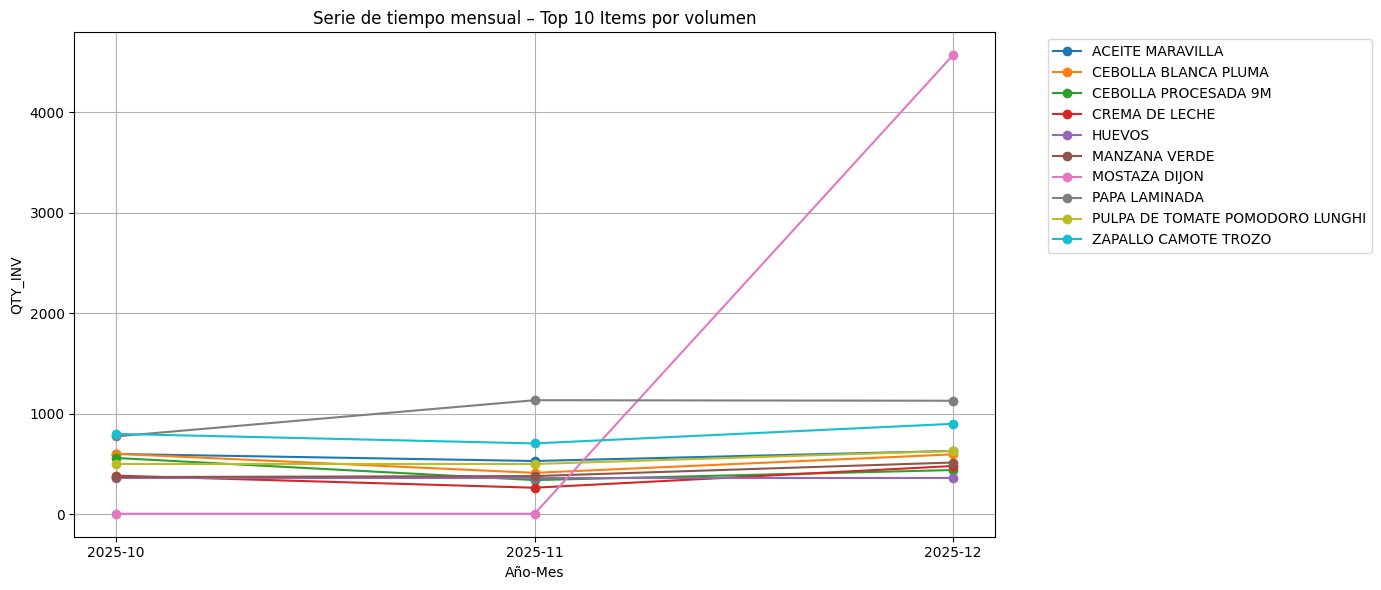

In [ ]:
import matplotlib.pyplot as plt

df_top10 = df_top10.copy()
df_top10['Mes'] = df_top10['Mes'].astype(str)

plt.figure(figsize=(14, 6))

for item, g in df_top10.groupby('Item Name'):
    g = g.sort_values('Mes')
    plt.plot(g['Mes'], g['QTY_INV'], marker='o', label=item)

plt.title('Serie de tiempo mensual – Top 10 Items por volumen')
plt.xlabel('Año-Mes')
plt.ylabel('QTY_INV')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# TD's

In [ ]:
pi

,Receta,Yield (Orig),Loss (%),Ingrediente Normalizado,Peso Final (Kg),%IPR,Octubre,Noviembre,Diciembre,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,2025,PRODUCCIÓN TOTAL DE RECETA,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Ají Encurtido CDP NFS,"51,00 kg",30.21,Ají Verde,29.709,0.4046,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,PRODUCTO,OCTUBRE,NOVIEMBRE,DICIEMBRE,ENERO
1,Ají Encurtido CDP NFS,"51,00 kg",30.21,Sal,2.451,0.0334,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJI ENCURTIDO CDP,0,0,0,0
2,Ají Encurtido CDP NFS,"51,00 kg",30.21,Azúcar Granulada,1.114,0.0152,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJO CONFITADO (PA) NFS,83.51,85,14,0
3,Ají Encurtido CDP NFS,"51,00 kg",30.21,"Vinagre Manzana (d=1,015)",30.155,0.4107,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJO Y ZANAHORIA CONFITADO NFS (PA),268.02,329.54,297.9,242.5
4,Ají Encurtido CDP NFS,"51,00 kg",30.21,Jengibre,0.149,0.0020,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,BABAGANUSH x KG LPR (PA),0,0,6.5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,Sopa de Zapallo LPR,"1,00 u",0.00,Curry en Polvo,0.001,0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447,Sopa de Zapallo LPR,"1,00 u",0.00,"Crema de Leche (d=1,02)",0.010,0.0218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,Sopa de Zapallo LPR,"1,00 u",0.00,"Aceite Oliva (d=0,915)",0.002,0.0039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
449,Sopa de Zapallo LPR,"1,00 u",0.00,"Focaccia Extra (0,35u x 0,135kg)",0.047,0.1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
pi2 = pi[pi["Ingrediente Normalizado"] != 'TOTAL RECETA']
pi2 = pi2[pi2["Ingrediente Normalizado"] != 'TOTAL INGRE']
pi2

,Receta,Yield (Orig),Loss (%),Ingrediente Normalizado,Peso Final (Kg),%IPR,Octubre,Noviembre,Diciembre,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,2025,PRODUCCIÓN TOTAL DE RECETA,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Ají Encurtido CDP NFS,"51,00 kg",30.21,Ají Verde,29.709,0.4046,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,PRODUCTO,OCTUBRE,NOVIEMBRE,DICIEMBRE,ENERO
1,Ají Encurtido CDP NFS,"51,00 kg",30.21,Sal,2.451,0.0334,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJI ENCURTIDO CDP,0,0,0,0
2,Ají Encurtido CDP NFS,"51,00 kg",30.21,Azúcar Granulada,1.114,0.0152,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJO CONFITADO (PA) NFS,83.51,85,14,0
3,Ají Encurtido CDP NFS,"51,00 kg",30.21,"Vinagre Manzana (d=1,015)",30.155,0.4107,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJO Y ZANAHORIA CONFITADO NFS (PA),268.02,329.54,297.9,242.5
4,Ají Encurtido CDP NFS,"51,00 kg",30.21,Jengibre,0.149,0.0020,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,BABAGANUSH x KG LPR (PA),0,0,6.5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Sopa de Zapallo LPR,"1,00 u",0.00,Semillas Maravilla,0.001,0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
446,Sopa de Zapallo LPR,"1,00 u",0.00,Curry en Polvo,0.001,0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447,Sopa de Zapallo LPR,"1,00 u",0.00,"Crema de Leche (d=1,02)",0.010,0.0218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,Sopa de Zapallo LPR,"1,00 u",0.00,"Aceite Oliva (d=0,915)",0.002,0.0039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_produccion2

,Mes,PRODUCTO,QTY_KG
0,2025-01,AJO Y ZANAHORIA CONFITADO NFS (PA),242.50
1,2025-01,BABAGANUSH x KG LPR (PA),13.00
2,2025-01,BOTON ENELDO (PA),10.00
3,2025-01,CALDO POLLO ARVERJADO CDP (PA),22.60
4,2025-01,CALENTITO CHARQUICAN NFS (PA),646.57
...,...,...,...
163,2025-12,RELLENO CAMARON,25.37
164,2025-12,RELLENO ENTRAÑA,101.72
165,2025-12,RELLENO POLLO,21.00
166,2025-12,SALSA POMODORO NFS (PA),42.80


In [ ]:
df_tmp = (
    df_produccion2
        .merge(
            pi2,
            left_on='PRODUCTO',
            right_on='Receta',
            how='left'
        )
)

# ===============================
# 2️⃣ Calcular cantidad por ingrediente
# ===============================
df_tmp['QTY_KG_ING'] = df_tmp['QTY_KG'] * df_tmp['%IPR']

# ===============================
# 3️⃣ Seleccionar columnas finales
# ===============================
df_produccion_ing = (
    df_tmp[[
        'Mes',
        'Ingrediente Normalizado',
        'QTY_KG_ING'
    ]]
)

df_produccion_ing

,Mes,Ingrediente Normalizado,QTY_KG_ING
0,2025-01,NaN,NaN
1,2025-01,NaN,NaN
2,2025-01,NaN,NaN
3,2025-01,NaN,NaN
4,2025-01,NaN,NaN
...,...,...,...
163,2025-12,NaN,NaN
164,2025-12,NaN,NaN
165,2025-12,NaN,NaN
166,2025-12,NaN,NaN


# Tablas finales

## 1) Produccion por mes

In [ ]:
df_produccion2

,Mes,PRODUCTO,QTY_KG
0,2025-01,AJO Y ZANAHORIA CONFITADO NFS (PA),242.50
1,2025-01,BABAGANUSH x KG LPR (PA),13.00
2,2025-01,BOTON ENELDO (PA),10.00
3,2025-01,CALDO POLLO ARVERJADO CDP (PA),22.60
4,2025-01,CALENTITO CHARQUICAN NFS (PA),646.57
...,...,...,...
163,2025-12,RELLENO CAMARON,25.37
164,2025-12,RELLENO ENTRAÑA,101.72
165,2025-12,RELLENO POLLO,21.00
166,2025-12,SALSA POMODORO NFS (PA),42.80


## 2) Transferencia a CP

In [ ]:
tr_pc2

,Transfer ID,From BU,To BU,Date,Status,Item Name,UOM,Qty,Cost,Extended Cost,UOM_ORIGINAL,UOM_INV,QTY_FACTOR,QTY_INV,Fecha,Mes
0,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,MENTA,Kilogramo,0.00,5990.000000,0.000000,Kilogramo,KG,1.0,0.00,2025-10-01,2025-10
1,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,AJO PELADO,Kilogramo,0.00,4990.000000,0.000000,Kilogramo,KG,1.0,0.00,2025-10-01,2025-10
2,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,PEPINO ENSALADA,Kilogramo,10.00,1700.000000,17000.000000,Kilogramo,KG,1.0,10.00,2025-10-01,2025-10
3,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,CEBOLLIN,Kilogramo,3.00,1750.000000,5250.000000,Kilogramo,KG,1.0,3.00,2025-10-01,2025-10
4,ST2509-01025 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-10-01,Booked,ESPINACA DESHOJADA,Kilogramo,50.00,3800.000000,190000.000000,Kilogramo,KG,1.0,50.00,2025-10-01,2025-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370,ST2512-01303 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-24,Booked,ENTRAÑA NO ROLL,Kilogramo,103.03,9700.000000,999391.000000,Kilogramo,KG,1.0,103.03,2025-12-24,2025-12
1371,ST2512-01308 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PECHUGA DE POLLO DESHUESADA,Kilogramo,20.60,3252.761506,67006.887019,Kilogramo,KG,1.0,20.60,2025-12-29,2025-12
1372,ST2601-00043 (Centro de Produccion Cocina),Centro de Produccion NFS,Centro de Produccion Cocina,2025-12-30,Booked,Carne Molida CDP Filete (PA) (PA),Kilogramo,81.00,1284.178899,104018.490830,Kilogramo,KG,1.0,81.00,2025-12-30,2025-12
1373,ST2601-00046 (Centro de Produccion Cocina),Bodega Natural Food,Centro de Produccion Cocina,2025-12-29,Booked,PAPA LAMINADA,Kilogramo,80.00,1090.000000,87200.000000,Kilogramo,KG,1.0,80.00,2025-12-29,2025-12


In [ ]:
df_mensual

,Mes,Item Name,QTY_INV
0,2025-10,@ MOLLEJAS CDP NFS (PA),40.0
1,2025-10,ACEITE FREIR,10.0
2,2025-10,ACEITE MARAVILLA,600.0
3,2025-10,ACEITE OLIVA,50.0
4,2025-10,AJI DE COLOR,11.0
...,...,...,...
346,2025-12,VINO TINTO COCINA,171.0
347,2025-12,ZANAHORIA PELADA,94.0
348,2025-12,ZANAHORIA PELADA CUBO,202.0
349,2025-12,ZAPALLO CAMOTE TROZO,900.0


In [ ]:
print(df_mensual["Item Name"].sort_values().unique()[:100])

<StringArray>
[         '@ BASE BROCHETA POLLO x KL',            '@ CHORIZO (PRUEBAS) (PA)',
                 '@ CUBO ASIENTO X KG',                    '@ MILANESA 200GR',
             '@ MOLLEJAS CDP NFS (PA)',                        'ACEITE FREIR',
                    'ACEITE MARAVILLA',                        'ACEITE OLIVA',
                       'AJI  DE COLOR',                        'AJO EN POLVO',
                          'AJO PELADO',                     'ALMIDON DE PAPA',
                         'APIO PELADO',                  'ARVEJAS CONGELADAS',
                      'ATUN AL ACEITE',                        'ATUN AL AGUA',
                    'AZUCAR GRANULADA',                       'Arroz grano 1',
                           'BERENJENA',                    'BETARRAGA PELADA',
                   'BONDIOLA DE CERDO',                             'BROCOLI',
                       'CAMARON 26 30',                       'CAMARON 36 40',
                 'CAMARON CON CASCARA'

## 3) Producción por ingredientes

In [ ]:
pi

,Receta,Yield (Orig),Loss (%),Ingrediente Normalizado,Peso Final (Kg),%IPR,Octubre,Noviembre,Diciembre,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,2025,PRODUCCIÓN TOTAL DE RECETA,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Ají Encurtido CDP NFS,"51,00 kg",30.21,Ají Verde,29.709,0.4046,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,PRODUCTO,OCTUBRE,NOVIEMBRE,DICIEMBRE,ENERO
1,Ají Encurtido CDP NFS,"51,00 kg",30.21,Sal,2.451,0.0334,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJI ENCURTIDO CDP,0,0,0,0
2,Ají Encurtido CDP NFS,"51,00 kg",30.21,Azúcar Granulada,1.114,0.0152,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJO CONFITADO (PA) NFS,83.51,85,14,0
3,Ají Encurtido CDP NFS,"51,00 kg",30.21,"Vinagre Manzana (d=1,015)",30.155,0.4107,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,AJO Y ZANAHORIA CONFITADO NFS (PA),268.02,329.54,297.9,242.5
4,Ají Encurtido CDP NFS,"51,00 kg",30.21,Jengibre,0.149,0.0020,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,BABAGANUSH x KG LPR (PA),0,0,6.5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,Sopa de Zapallo LPR,"1,00 u",0.00,Curry en Polvo,0.001,0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447,Sopa de Zapallo LPR,"1,00 u",0.00,"Crema de Leche (d=1,02)",0.010,0.0218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,Sopa de Zapallo LPR,"1,00 u",0.00,"Aceite Oliva (d=0,915)",0.002,0.0039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
449,Sopa de Zapallo LPR,"1,00 u",0.00,"Focaccia Extra (0,35u x 0,135kg)",0.047,0.1009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Lectura tablas externas: Recetas e Ingredientes por Receta

In [ ]:
df_recipes = pd.read_excel("Recetas.xlsx")
df_ingredients = pd.read_excel("Ingredientes.xlsx")

In [ ]:
df_recipes

,recipe_name,version,production_center,portion_qty,portion_size,portion_unit,recipe_yield,yield_unit,loss_pct,recipe_id
0,@ AJI ENCURTIDO CDP NFS,19,Cocina,"51,00","1,00",kg,"51,00",kg,"30,21 %",1
1,@ ENCURTIDO AJI VERDE Y REPOLLO LC,8,Cocina,"250,00","1,00",kg,"250,00",kg,"14,68 %",2
2,AJOS CONFITADO,14,Cocina,"5,50","1,00",kg,"5,50",kg,"0,00 %",3
3,@AJO Y ZANAHORIA CONFITADO NFS,7,Cocina,"10,20","1,00",kg,"10,20",kg,"0,00 %",4
4,Babaganush,24,Cocina,"21,34","1,00",kg,"21,34",kg,"0,00 %",5
...,...,...,...,...,...,...,...,...,...,...
57,@ RELLENO DE POLLO NFS,3,CP Heladeria NFS,"20,00","1,00",kg,"20,00",kg,"19,19 %",58
58,@ RELLENO VEGETARIANO NFS,4,CP Heladeria NFS,"15,00","1,00",kg,"15,00",kg,"-21,95 %",59
59,@ SALSA BOLGNESA B NFS,4,Cocina,"4,20","1,00",kg,"4,20",kg,"47,53 %",60
60,@ SALSA POMODORO NFS,23,La Cabrera Alonso,"30,12","1,00",lt,"30,12",lt,"0,00 %",61


In [ ]:
df_ingredients

,Unnamed: 0.1,Unnamed: 0,Pos,Type,Ingredient,POT QTY,Std. Port,Volume,Loss,Loss2,ACT QTY,BU,Prep. Type,recipe_id,page,portion_qty,Ingrediente,Densidad,ACT QTY (Kg),pct_recipe
0,0,0,1.0,NaN,AJI VERDE,"29,709",kg,NaN,NaN,NaN,"29,7087",Kilogramo,NaN,1,1,51.0,NaN,1.000,29.708700,58.252353
1,1,1,2.0,NaN,SAL,"2,451",kg,NaN,NaN,NaN,"2,4510",Kilogramo,NaN,1,1,51.0,NaN,1.000,2.451000,4.805882
2,2,2,3.0,NaN,AZUCAR GRANULADA,"1,114",kg,NaN,NaN,NaN,"1,1141",Kilogramo,NaN,1,1,51.0,NaN,1.000,1.114100,2.184510
3,3,3,4.0,NaN,VINAGRE MANZANA,"29,709",lt,NaN,NaN,NaN,"29,7087",Litro,NaN,1,1,51.0,VINAGRE MANZANA,1.015,30.154331,59.126138
4,4,4,5.0,NaN,JENGIBRE,"0,149",kg,NaN,NaN,NaN,"0,1485",Kilogramo,NaN,1,1,51.0,NaN,1.000,0.148500,0.291176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,401,419,3.0,NaN,SEMILLAS MARAVILLA,"1,000",gr,NaN,NaN,NaN,"0,0010",Kilogramo,NaN,62,62,1.0,NaN,1.000,0.001000,0.100000
402,402,420,4.0,NaN,CURRY EN POLVO,"1,000",gr,NaN,NaN,NaN,"0,0010",Kilogramo,NaN,62,62,1.0,NaN,1.000,0.001000,0.100000
403,403,421,5.0,NaN,CREMA DE LECHE,"10,000",ml,NaN,NaN,NaN,"0,0100",Litro,NaN,62,62,1.0,CREMA DE LECHE,1.020,0.010200,1.020000
404,404,422,6.0,NaN,ACEITE OLIVA,"2,000",ml,NaN,NaN,NaN,"0,0020",Litro,NaN,62,62,1.0,ACEITE OLIVA,0.915,0.001830,0.183000


# Cruce Produccion - Ingredientes

In [ ]:
nombres = pd.read_excel("BD.xlsx", sheet_name='NombresRecetas')
nombres.head()

,Nombre Produccion,Nombre Receta
0,AJI ENCURTIDO CDP,@ AJI ENCURTIDO CDP NFS
1,AJO CONFITADO (PA) NFS,AJOS CONFITADO
2,AJO Y ZANAHORIA CONFITADO NFS (PA),@AJO Y ZANAHORIA CONFITADO NFS
3,BABAGANUSH x KG LPR (PA),Babaganush
4,BOTON GREEN NFS (PA),@ BOTON GREEN NFS


In [ ]:
df_produccion3 = df_produccion2.merge(nombres, how='left', left_on='PRODUCTO', right_on='Nombre Produccion')
df_produccion3 = df_produccion3.dropna(subset='Nombre Receta')
df_produccion3

,Mes,PRODUCTO,QTY_KG,Nombre Produccion,Nombre Receta
0,2025-01,AJO Y ZANAHORIA CONFITADO NFS (PA),242.50,AJO Y ZANAHORIA CONFITADO NFS (PA),@AJO Y ZANAHORIA CONFITADO NFS
1,2025-01,BABAGANUSH x KG LPR (PA),13.00,BABAGANUSH x KG LPR (PA),Babaganush
3,2025-01,CALDO POLLO ARVERJADO CDP (PA),22.60,CALDO POLLO ARVERJADO CDP (PA),Caldo Pollo Arvejado CDP
4,2025-01,CALENTITO CHARQUICAN NFS (PA),646.57,CALENTITO CHARQUICAN NFS (PA),CALENTITO CHARQUICAN
5,2025-01,CALENTITO PURE DE MANZANA (PA),180.62,CALENTITO PURE DE MANZANA (PA),@ CALENTITO PURE DE MANZANA NFS
...,...,...,...,...,...
162,2025-12,RELICH PEPINO,122.80,RELICH PEPINO,@ RELISH PEPINO CDP NFS
163,2025-12,RELLENO CAMARON,25.37,RELLENO CAMARON,@ RELLENO DE CAMARON NFS
164,2025-12,RELLENO ENTRAÑA,101.72,RELLENO ENTRAÑA,@ RELLENO DE ENTRAÑA NFS
165,2025-12,RELLENO POLLO,21.00,RELLENO POLLO,@ RELLENO DE POLLO NFS


In [ ]:
prod_recetas_mes = df_produccion3.merge(df_recipes, how='left', left_on='Nombre Receta', right_on='recipe_name')
prod_recetas_mes

,Mes,PRODUCTO,QTY_KG,Nombre Produccion,Nombre Receta,recipe_name,version,production_center,portion_qty,portion_size,portion_unit,recipe_yield,yield_unit,loss_pct,recipe_id
0,2025-01,AJO Y ZANAHORIA CONFITADO NFS (PA),242.50,AJO Y ZANAHORIA CONFITADO NFS (PA),@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,7,Cocina,"10,20","1,00",kg,"10,20",kg,"0,00 %",4
1,2025-01,BABAGANUSH x KG LPR (PA),13.00,BABAGANUSH x KG LPR (PA),Babaganush,Babaganush,24,Cocina,"21,34","1,00",kg,"21,34",kg,"0,00 %",5
2,2025-01,CALDO POLLO ARVERJADO CDP (PA),22.60,CALDO POLLO ARVERJADO CDP (PA),Caldo Pollo Arvejado CDP,Caldo Pollo Arvejado CDP,9,Cocina,"33,52","1,00",kg,"33,52",kg,"1,46 %",11
3,2025-01,CALENTITO CHARQUICAN NFS (PA),646.57,CALENTITO CHARQUICAN NFS (PA),CALENTITO CHARQUICAN,CALENTITO CHARQUICAN,18,Cocina,"120,00","1,00",kg,"120,00",kg,"5,70 %",12
4,2025-01,CALENTITO PURE DE MANZANA (PA),180.62,CALENTITO PURE DE MANZANA (PA),@ CALENTITO PURE DE MANZANA NFS,@ CALENTITO PURE DE MANZANA NFS,18,Cocina,"68,00","1,00",kg,"68,00",kg,"16,05 %",13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,2025-12,RELICH PEPINO,122.80,RELICH PEPINO,@ RELISH PEPINO CDP NFS,@ RELISH PEPINO CDP NFS,11,La Cabrera Alonso,"32,00","1,00",kg,"32,00",kg,"33,26 %",54
131,2025-12,RELLENO CAMARON,25.37,RELLENO CAMARON,@ RELLENO DE CAMARON NFS,@ RELLENO DE CAMARON NFS,3,CP Heladeria NFS,"8,50","1,00",kg,"8,50",kg,"40,77 %",56
132,2025-12,RELLENO ENTRAÑA,101.72,RELLENO ENTRAÑA,@ RELLENO DE ENTRAÑA NFS,@ RELLENO DE ENTRAÑA NFS,6,CP Heladeria NFS,"20,00","1,00",kg,"20,00",kg,"57,36 %",57
133,2025-12,RELLENO POLLO,21.00,RELLENO POLLO,@ RELLENO DE POLLO NFS,@ RELLENO DE POLLO NFS,3,CP Heladeria NFS,"20,00","1,00",kg,"20,00",kg,"19,19 %",58


In [ ]:
df_ingredients = pd.read_excel("BD.xlsx", sheet_name='IPR')
df_ingredients

,Unnamed: 0,Pos,NAME,recipe_id,Ingredient,POT QTY,Std. Port,Densidad,Loss,Loss2,ACT QTY,BU,Prep. Type,recipe_id.1,page,%IPR
0,0.0,1.0,@ AJI ENCURTIDO CDP NFS,1,AJI VERDE,"29,709",kg,NaN,NaN,NaN,29.708700,Kilogramo,NaN,1,1,0.582524
1,1.0,2.0,@ AJI ENCURTIDO CDP NFS,1,SAL,"2,451",kg,NaN,NaN,NaN,2.451000,Kilogramo,NaN,1,1,0.048059
2,2.0,3.0,@ AJI ENCURTIDO CDP NFS,1,AZUCAR GRANULADA,"1,114",kg,NaN,NaN,NaN,1.114100,Kilogramo,NaN,1,1,0.021845
3,3.0,4.0,@ AJI ENCURTIDO CDP NFS,1,VINAGRE MANZANA,"29,709",lt,1.015,NaN,NaN,30.154635,Kilogramo,NaN,1,1,0.591267
4,4.0,5.0,@ AJI ENCURTIDO CDP NFS,1,JENGIBRE,"0,149",kg,NaN,NaN,NaN,0.148500,Kilogramo,NaN,1,1,0.002912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,419.0,3.0,SOPA DE ZAPALLO,62,SEMILLAS MARAVILLA,"1,000",gr,NaN,NaN,NaN,0.001000,Kilogramo,NaN,62,62,NaN
395,420.0,4.0,SOPA DE ZAPALLO,62,CURRY EN POLVO,"1,000",gr,NaN,NaN,NaN,0.001000,Kilogramo,NaN,62,62,NaN
396,421.0,5.0,SOPA DE ZAPALLO,62,CREMA DE LECHE,0.01,lt,1.020,NaN,NaN,0.010200,Kilogramo,NaN,62,62,NaN
397,422.0,6.0,SOPA DE ZAPALLO,62,ACEITE OLIVA,0.002,lt,0.915,NaN,NaN,0.001830,Kilogramo,NaN,62,62,NaN


In [ ]:
df_ingredients.columns

Index(['Unnamed: 0', 'Pos', 'NAME', 'recipe_id', 'Ingredient', 'POT QTY',
       'Std. Port', 'Densidad ', 'Loss', 'Loss2', 'ACT QTY', 'BU',
       'Prep. Type', 'recipe_id.1', 'page', '%IPR'],
      dtype='str')

In [ ]:
prod_ingredientes_mes = prod_recetas_mes[["Mes", "QTY_KG", "Nombre Receta"]].merge(df_ingredients[['NAME', 'recipe_id', 'Ingredient', 'BU', '%IPR']], how='left', left_on='Nombre Receta', right_on='NAME')
prod_ingredientes_mes

,Mes,QTY_KG,Nombre Receta,NAME,recipe_id,Ingredient,BU,%IPR
0,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AJO PELADO,Kilogramo,0.490196
1,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AJI DE COLOR,Kilogramo,0.019608
2,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AZUCAR GRANULADA,Kilogramo,0.196078
3,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,ZANAHORIA PELADA CUBO,Kilogramo,0.294118
4,2025-01,13.0,Babaganush,Babaganush,5,ACEITE OLIVA,Kilogramo,0.090471
...,...,...,...,...,...,...,...,...
882,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,OREGANO,Kilogramo,0.000996
883,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,@ AJO CONFITADO (PA) NFS,Kilogramo,0.000332
884,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,SAL,Kilogramo,0.00166
885,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,PIMIENTA NEGRA MOLIDA,Kilogramo,0.000166


In [ ]:
prod_ingredientes_mes["Total Prod Ingrediente - Receta"] = prod_ingredientes_mes["QTY_KG"]*prod_ingredientes_mes["%IPR"]
prod_ingredientes_mes

,Mes,QTY_KG,Nombre Receta,NAME,recipe_id,Ingredient,BU,%IPR,Total Prod Ingrediente - Receta
0,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AJO PELADO,Kilogramo,0.490196,118.872549
1,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AJI DE COLOR,Kilogramo,0.019608,4.754902
2,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AZUCAR GRANULADA,Kilogramo,0.196078,47.54902
3,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,ZANAHORIA PELADA CUBO,Kilogramo,0.294118,71.323529
4,2025-01,13.0,Babaganush,Babaganush,5,ACEITE OLIVA,Kilogramo,0.090471,1.176122
...,...,...,...,...,...,...,...,...,...
882,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,OREGANO,Kilogramo,0.000996,0.042629
883,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,@ AJO CONFITADO (PA) NFS,Kilogramo,0.000332,0.01421
884,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,SAL,Kilogramo,0.00166,0.071049
885,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,PIMIENTA NEGRA MOLIDA,Kilogramo,0.000166,0.007105


In [ ]:
prod_ingredientes_mes.to_excel("Producción por Ingredientes - Mensual.xlsx", index=False)

In [ ]:
prod_ingredientes_mes["Total Prod Ingrediente"] = prod_ingredientes_mes.groupby(["Mes", "Ingredient"])['Total Prod Ingrediente - Receta'].transform('sum')
prod_ingredientes_mes

,Mes,QTY_KG,Nombre Receta,NAME,recipe_id,Ingredient,BU,%IPR,Total Prod Ingrediente - Receta,Total Prod Ingrediente
0,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AJO PELADO,Kilogramo,0.490196,118.872549,121.79963
1,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AJI DE COLOR,Kilogramo,0.019608,4.754902,7.311993
2,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,AZUCAR GRANULADA,Kilogramo,0.196078,47.54902,96.462151
3,2025-01,242.5,@AJO Y ZANAHORIA CONFITADO NFS,@AJO Y ZANAHORIA CONFITADO NFS,4,ZANAHORIA PELADA CUBO,Kilogramo,0.294118,71.323529,147.230529
4,2025-01,13.0,Babaganush,Babaganush,5,ACEITE OLIVA,Kilogramo,0.090471,1.176122,49.636177
...,...,...,...,...,...,...,...,...,...,...
882,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,OREGANO,Kilogramo,0.000996,0.042629,28.269474
883,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,@ AJO CONFITADO (PA) NFS,Kilogramo,0.000332,0.01421,2.621353
884,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,SAL,Kilogramo,0.00166,0.071049,75.505156
885,2025-12,42.8,@ SALSA POMODORO NFS,@ SALSA POMODORO NFS,61,PIMIENTA NEGRA MOLIDA,Kilogramo,0.000166,0.007105,0.01472


In [ ]:
prod_ingredientes_mes.columns

Index(['Mes', 'QTY_KG', 'Nombre Receta', 'NAME', 'recipe_id', 'Ingredient',
       'BU', '%IPR', 'Total Prod Ingrediente - Receta',
       'Total Prod Ingrediente'],
      dtype='str')

In [ ]:
prod_ingredientes_mes_agrupado = prod_ingredientes_mes[['Mes', 'Ingredient', 'Total Prod Ingrediente']]
prod_ingredientes_mes_agrupado = prod_ingredientes_mes_agrupado.drop_duplicates()
prod_ingredientes_mes_agrupado

,Mes,Ingredient,Total Prod Ingrediente
0,2025-01,AJO PELADO,121.79963
1,2025-01,AJI DE COLOR,7.311993
2,2025-01,AZUCAR GRANULADA,96.462151
3,2025-01,ZANAHORIA PELADA CUBO,147.230529
4,2025-01,ACEITE OLIVA,49.636177
...,...,...,...
872,2025-12,SALSA SOYA JAPONESA O CHINA OSCURA,3.0516
873,2025-12,SUB ACEITE CARBON NFS,15.258
874,2025-12,TRUTROS DE POLLO DESHUESADO,21.0
877,2025-12,LECHE DE COCO,1.2789


In [ ]:
prod_ingredientes_mes_agrupado.sort_values(by=["Ingredient"])

,Mes,Ingredient,Total Prod Ingrediente
647,2025-12,"1,2KILOS POCHADA",0.0
169,2025-10,"1,2KILOS POCHADA",0.0
420,2025-11,"1,2KILOS POCHADA",0.0
348,2025-10,@ AJO CONFITADO (PA) NFS,2.56
95,2025-01,@ AJO CONFITADO (PA) NFS,2.347504
...,...,...,...
418,2025-11,ZANAHORIA PELADA CUBO,246.527529
659,2025-12,ZAPALLO CAMOTE TROZO,909.457436
21,2025-01,ZAPALLO CAMOTE TROZO,337.831026
432,2025-11,ZAPALLO CAMOTE TROZO,674.487692


# Cruce Transferencia - Ingredientes

In [ ]:
df_mensual

,Mes,Item Name,QTY_INV
0,2025-10,@ MOLLEJAS CDP NFS (PA),40.0
1,2025-10,ACEITE FREIR,10.0
2,2025-10,ACEITE MARAVILLA,600.0
3,2025-10,ACEITE OLIVA,50.0
4,2025-10,AJI DE COLOR,11.0
...,...,...,...
346,2025-12,VINO TINTO COCINA,171.0
347,2025-12,ZANAHORIA PELADA,94.0
348,2025-12,ZANAHORIA PELADA CUBO,202.0
349,2025-12,ZAPALLO CAMOTE TROZO,900.0


In [ ]:
prod_ingredientes_mes_agrupado["Mes"] = pd.to_datetime(
    prod_ingredientes_mes_agrupado["Mes"]
).dt.to_period("M")

In [ ]:
prod_transf_ingredientes = prod_ingredientes_mes_agrupado.merge(df_mensual, how='outer', left_on=["Mes", "Ingredient"], right_on=["Mes", "Item Name"])
prod_transf_ingredientes

,Mes,Ingredient,Total Prod Ingrediente,Item Name,QTY_INV
0,2025-01,@ AJO CONFITADO (PA) NFS,2.347504,NaN,NaN
1,2025-01,@ BASE CEVICHE CDP NFS,13.538462,NaN,NaN
2,2025-01,@ CEBOLLA CARAMELIZADA NFS (PA),1.06,NaN,NaN
3,2025-01,ACEITE MARAVILLA,209.116576,NaN,NaN
4,2025-01,ACEITE OLIVA,49.636177,NaN,NaN
...,...,...,...,...,...
499,2025-12,VINO TINTO COCINA,156.564353,VINO TINTO COCINA,171.0
500,2025-12,ZANAHORIA PELADA,87.694795,ZANAHORIA PELADA,94.0
501,2025-12,ZANAHORIA PELADA CUBO,206.900647,ZANAHORIA PELADA CUBO,202.0
502,2025-12,ZAPALLO CAMOTE TROZO,909.457436,ZAPALLO CAMOTE TROZO,900.0


In [ ]:
prod_transf_ingredientes["Diferencia"] = prod_transf_ingredientes["Total Prod Ingrediente"] - prod_transf_ingredientes["QTY_INV"]
prod_transf_ingredientes

,Mes,Ingredient,Total Prod Ingrediente,Item Name,QTY_INV,Diferencia
0,2025-01,@ AJO CONFITADO (PA) NFS,2.347504,NaN,NaN,NaN
1,2025-01,@ BASE CEVICHE CDP NFS,13.538462,NaN,NaN,NaN
2,2025-01,@ CEBOLLA CARAMELIZADA NFS (PA),1.06,NaN,NaN,NaN
3,2025-01,ACEITE MARAVILLA,209.116576,NaN,NaN,NaN
4,2025-01,ACEITE OLIVA,49.636177,NaN,NaN,NaN
...,...,...,...,...,...,...
499,2025-12,VINO TINTO COCINA,156.564353,VINO TINTO COCINA,171.0,-14.435647
500,2025-12,ZANAHORIA PELADA,87.694795,ZANAHORIA PELADA,94.0,-6.305205
501,2025-12,ZANAHORIA PELADA CUBO,206.900647,ZANAHORIA PELADA CUBO,202.0,4.900647
502,2025-12,ZAPALLO CAMOTE TROZO,909.457436,ZAPALLO CAMOTE TROZO,900.0,9.457436


In [ ]:
prod_transf_ingredientes.to_excel("Produccion y Transferencia de Ingredientes por mes.xlsx", index=False)

PermissionError: [Errno 13] Permission denied: 'Produccion y Transferencia de Ingredientes por mes.xlsx'

# Cierre Inventario

In [ ]:
cierre_inv = pd.read_excel("BD.xlsx", sheet_name='CierreInventario')
cierre_inv

,Fecha,Tipo,Num.Articulo,Articulo,Unidad,Cantidad contada,Conteo,Valor conteo,Listo para contar,POT CDAD,Var. Qty,Precio,Var_Valor
0,2025-10-01,ABARROTES,3004.0,ACEITE FREIR,Litro,0.0,0.0,0.0,0.0,10.00000,"-10,000",1600.0,-16000.00000
1,2025-10-01,ABARROTES,3005.0,ACEITE MARAVILLA,Litro,70.0,70.0,125300.0,0.0,70.60210,"-0,602",1790.0,-1077.75900
2,2025-10-01,ABARROTES,3000.0,ACEITE OLIVA,Litro,25.0,25.0,200000.0,0.0,24.88160,"0,118",8000.0,947.20000
3,2025-10-01,ABARROTES,3010.0,ACEITUNA VERDE ENTERA SIN CAROZO,Bolsa 1 Kilo,0.0,0.0,0.0,0.0,-0.50000,"0,500",3875.0,1937.50000
4,2025-10-01,ABARROTES,3013.0,AJI CACHO CABRA,Bolsa 1 Kilo,2.0,2.0,17050.0,0.0,1.35625,"0,644",8525.0,5487.96875
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1256,2025-12-01,VERDURAS FRUTAS,1327.0,ZANAHORIA PELADA CUBO,Kilogramo,8.0,8.0,9600.0,0.0,23.87500,"-15,875",1200.0,-19050.00000
1257,2025-12-01,VERDURAS FRUTAS,630.0,ZAPALLO CAMOTE,Kilogramo,0.0,0.0,0.0,0.0,0.00000,"0,000",790.0,0.00000
1258,2025-12-01,VERDURAS FRUTAS,1304.0,ZAPALLO CAMOTE CUBO,Kilogramo,0.0,0.0,0.0,0.0,0.00000,"0,000",1300.0,0.00000
1259,2025-12-01,VERDURAS FRUTAS,1312.0,ZAPALLO CAMOTE TROZO,Kilogramo,80.0,80.0,87200.0,0.0,65.53847,"14,462",1090.0,15763.06770


In [ ]:
cierre_inv = cierre_inv[['Fecha', 'Tipo', 'Articulo', 'Unidad', 'Cantidad contada']]
cierre_inv

,Fecha,Tipo,Articulo,Unidad,Cantidad contada
0,2025-10-01,ABARROTES,ACEITE FREIR,Litro,0.0
1,2025-10-01,ABARROTES,ACEITE MARAVILLA,Litro,70.0
2,2025-10-01,ABARROTES,ACEITE OLIVA,Litro,25.0
3,2025-10-01,ABARROTES,ACEITUNA VERDE ENTERA SIN CAROZO,Bolsa 1 Kilo,0.0
4,2025-10-01,ABARROTES,AJI CACHO CABRA,Bolsa 1 Kilo,2.0
...,...,...,...,...,...
1256,2025-12-01,VERDURAS FRUTAS,ZANAHORIA PELADA CUBO,Kilogramo,8.0
1257,2025-12-01,VERDURAS FRUTAS,ZAPALLO CAMOTE,Kilogramo,0.0
1258,2025-12-01,VERDURAS FRUTAS,ZAPALLO CAMOTE CUBO,Kilogramo,0.0
1259,2025-12-01,VERDURAS FRUTAS,ZAPALLO CAMOTE TROZO,Kilogramo,80.0


In [ ]:
cierre_inv["Mes"] = pd.to_datetime(
    cierre_inv["Fecha"]
).dt.to_period("M")

cierre_inv

,Fecha,Tipo,Articulo,Unidad,Cantidad contada,Mes
0,2025-10-01,ABARROTES,ACEITE FREIR,Litro,0.0,2025-10
1,2025-10-01,ABARROTES,ACEITE MARAVILLA,Litro,70.0,2025-10
2,2025-10-01,ABARROTES,ACEITE OLIVA,Litro,25.0,2025-10
3,2025-10-01,ABARROTES,ACEITUNA VERDE ENTERA SIN CAROZO,Bolsa 1 Kilo,0.0,2025-10
4,2025-10-01,ABARROTES,AJI CACHO CABRA,Bolsa 1 Kilo,2.0,2025-10
...,...,...,...,...,...,...
1256,2025-12-01,VERDURAS FRUTAS,ZANAHORIA PELADA CUBO,Kilogramo,8.0,2025-12
1257,2025-12-01,VERDURAS FRUTAS,ZAPALLO CAMOTE,Kilogramo,0.0,2025-12
1258,2025-12-01,VERDURAS FRUTAS,ZAPALLO CAMOTE CUBO,Kilogramo,0.0,2025-12
1259,2025-12-01,VERDURAS FRUTAS,ZAPALLO CAMOTE TROZO,Kilogramo,80.0,2025-12


In [2]:
prod_transf_ingredientes_cierre = prod_transf_ingredientes.merge(cierre_inv, how='outer', left_on=["Mes", "Ingredient"], right_on=["Mes", "Articulo"])
prod_transf_ingredientes_cierre

NameError: name 'prod_transf_ingredientes' is not defined

In [ ]:
prod_transf_ingredientes_cierre.to_excel("Produccion y Transferencia de Ingredientes por mes - Cierre de Inventario.xlsx", index=False)